In [7]:
from pathlib import Path
import pickle
import sys
import os
sys.path.append('../')

DATA_DIR = Path('../data/100000_data_points')
DATA_PATH = DATA_DIR / "synthetic_rl_datasets.pkl"
try:
    with open(DATA_PATH, 'rb') as f:
        all_data = pickle.load(f)
except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")
except Exception as e:
    print(f"Error loading dataset: {e}")


In [ ]:

key = '6x6_2_agents'
data = all_data[key]

NUM_DATA_POINTS = 100000

p_pick_apple = 0.1

num_picks_apple = int(NUM_DATA_POINTS * p_pick_apple)
num_no_picks_apple = NUM_DATA_POINTS - num_picks_apple

data_with_apple = data['picks_apple'][:num_picks_apple]
data_without_apple = data['doesnt_pick_apple'][:num_no_picks_apple]





In [ ]:
import random

state_agentpos_reward = data_with_apple + data_without_apple
random.seed(42)  # Set a random seed for reproducibility TODO
print(len(state_agentpos_reward))
print(state_agentpos_reward[0])

percent_train = 0.8
total_train = int(0.8 * NUM_DATA_POINTS)
state_agentpos_reward_TRAIN = state_agentpos_reward[:total_train]
state_agentpos_reward_TEST = state_agentpos_reward[total_train:]

100000
{'state': {'apples': array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0]], dtype=int8), 'agents': array([[0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int8)}, 'agent_pos': (np.int64(1), np.int64(1)), 'reward': 0}


In [10]:
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNCentralized
from tests.cnn.centralized.generate_synthetic_states import (
    generate_synthetic_state_at_most_1_apples,
)
from config import MODEL_DIR, GRAPHS_DIR

WIDTH = 6
HEIGHT = 6
NUM_AGENTS = 2
NUM_TRAIN_EPISODES = 1000
BATCH_SIZE = 32
lr = 0.01

model = RewardCNNCentralized(WIDTH, HEIGHT, lr)
# --- Training Loop ---
for i in tqdm(range(NUM_TRAIN_EPISODES), desc="Training"):
    for b in range(BATCH_SIZE):
        row_index = i * BATCH_SIZE + b
        state = state_agentpos_reward_TRAIN[row_index]["state"]
        label = state_agentpos_reward_TRAIN[row_index]["reward"]
        model.add_experience_from_raw(state, label)
    model.train_batch()
print(f"Final loss after training: {model.loss_history[-1]}")

Training: 100%|██████████| 1000/1000 [00:02<00:00, 368.06it/s]

Final loss after training: 7.257816832861863e-06


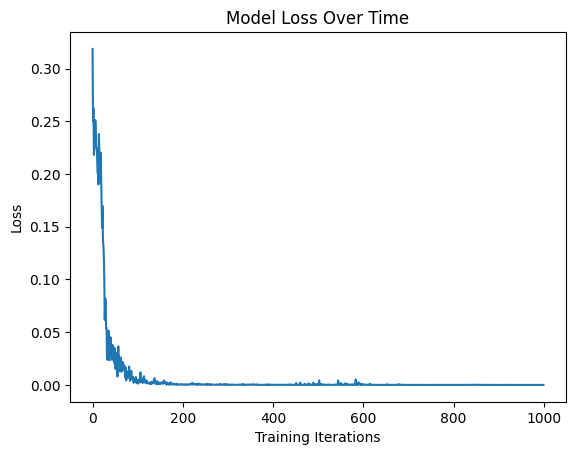

In [11]:
# plot model loss
plt.plot(model.loss_history)
plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Model Loss Over Time")
plt.savefig(GRAPHS_DIR / f"cnn_centralized_loss_{p_pick_apple}.png")

100%|██████████| 4/4 [00:42<00:00, 10.58s/it]


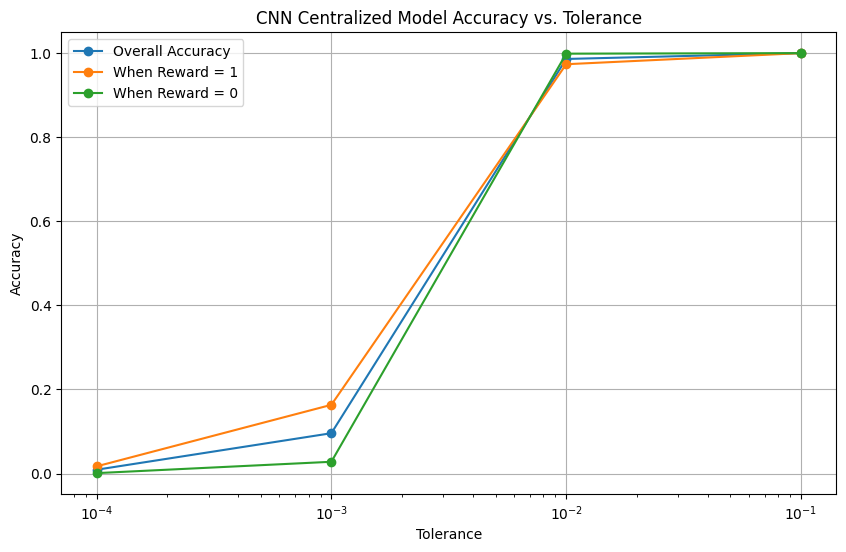

In [12]:
import torch
from tests.cnn.centralized.generate_synthetic_states import (
    generate_synthetic_state_at_most_1_apples,
)
from train_scripts.train_centralized_cnn import MODEL_SAVE_PATH
import matplotlib.pyplot as plt
from config import GRAPHS_DIR
from tqdm import tqdm


# --- Configuration (should match the trained model) ---
num_test_episodes = len(state_agentpos_reward_TEST)
tols = [0.1, 0.01, 0.001, 0.0001]
num_agents = 2

#TODO PLOT accuracy when reward is 1, when reward is 0.
accuracies_when_reward_1 = []
accuracies_when_reward_0 = []
accuracies = []
for tol in tqdm(tols):
    # --- Test Loop (no training here!) ---
    num_correct = 0
    num_correct_when_reward_1 = 0
    num_correct_when_reward_0 = 0
    num_reward_1 = 0
    num_reward_0 = 0
    for i in tqdm(range(num_test_episodes), leave=False):
        state = state_agentpos_reward_TEST[i]["state"]
        label = state_agentpos_reward_TEST[i]["reward"]
        # Get the raw float prediction
        prediction = model.get_model_reward_prediction_from_raw(state).item()
        error = abs(prediction - label)
        if error < tol:
            num_correct += 1
        if label == 1:
            num_reward_1 += 1
            if error < tol:
                num_correct_when_reward_1 += 1
        else:
            num_reward_0 += 1
            if error < tol:
                num_correct_when_reward_0 += 1
    accuracy = num_correct / num_test_episodes
    accuracies.append(accuracy)
    if num_reward_1 > 0:
        accuracy_when_reward_1 = num_correct_when_reward_1 / num_reward_1
    else:
        accuracy_when_reward_1 = 0
    accuracies_when_reward_1.append(accuracy_when_reward_1)
    if num_reward_0 > 0:
        accuracy_when_reward_0 = num_correct_when_reward_0 / num_reward_0
    else:
        accuracy_when_reward_0 = 0
    accuracies_when_reward_0.append(accuracy_when_reward_0)
    
plt.figure(figsize=(10, 6))
plt.plot(tols, accuracies, marker="o", label="Overall Accuracy")
plt.plot(tols, accuracies_when_reward_1, marker="o", label="When Reward = 1")
plt.plot(tols, accuracies_when_reward_0, marker="o", label="When Reward = 0")
plt.legend()
plt.xscale("log")
plt.xlabel("Tolerance")
plt.ylabel("Accuracy")
plt.title("CNN Centralized Model Accuracy vs. Tolerance")
plt.grid(True)
plt.savefig(f"{GRAPHS_DIR}/cnn_centralized_accuracy_vs_tolerance_{p_pick_apple}p.png")
